# Story 1: "The Year Nature Went Wild" 🌪️

## External Data Correlation: Hurricane Impact on MCO & MIA Airports (2004-2005)

**The Narrative:**

2004 was the year Florida couldn't catch a break. Four major hurricanes - Charley, Frances, Ivan, and Jeanne - battered the state in just 6 weeks. Then 2005 brought the costliest hurricane season in history, with Katrina, Rita, and Wilma. 

This analysis explores:
- How did each hurricane impact flight operations at MCO (Orlando) and MIA (Miami)?
- Which airport demonstrated better resilience and faster recovery?
- Did airlines adapt their operations after the devastating 2004 season?
- What secondary effects rippled through the system days after the storms passed?

---

## Section 1: Setup and Data Loading

In [ ]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from pandas import Timedelta as timedelta
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 6)

# Color scheme
COLORS = {
    'MCO': '#3498db',      # Blue
    'MIA': '#e74c3c',      # Red
    'Cancellations': '#e74c3c',  # Red
    'WeatherDelay': '#f39c12',   # Orange
    'Hurricane': '#2c3e50'       # Dark gray
}

print("✓ Libraries imported successfully")

In [ ]:
# Load main flight data
print("Loading flight data...")
df = pd.read_csv('../data/processed/mco_mia_clean.csv.gz',
                  parse_dates=['FlightDate'],
                  compression='gzip')

print(f"Loaded {len(df):,} flight records")
print(f"Date range: {df['FlightDate'].min()} to {df['FlightDate'].max()}")
print(f"Columns: {df.columns.tolist()}")

Loading flight data...
Loaded 1,592,198 flight records
Date range: 2004-01-01 00:00:00 to 2008-04-30 00:00:00
Columns: ['Year', 'Month', 'DayofMonth', 'DayOfWeek', 'DepTime', 'CRSDepTime', 'ArrTime', 'CRSArrTime', 'UniqueCarrier', 'FlightNum', 'TailNum', 'ActualElapsedTime', 'CRSElapsedTime', 'AirTime', 'ArrDelay', 'DepDelay', 'Origin', 'Dest', 'Distance', 'TaxiIn', 'TaxiOut', 'Cancelled', 'CancellationCode', 'Diverted', 'CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay', 'FlightDate', 'CRSDepTime_Hour', 'CRSDepTime_Min', 'DepTime_Hour', 'DepTime_Min', 'CRSArrTime_Hour', 'CRSArrTime_Min', 'ArrTime_Hour', 'ArrTime_Min', 'OnTime', 'DelayCategory', 'Quarter', 'IsHolidaySeason', 'DayName', 'IsMCO', 'IsMIA', 'MCO_Direction', 'MIA_Direction', 'TimeOfDay', 'IsWeekend', 'DistanceCategory', 'Season', 'PrimaryDelayCause']


In [ ]:
# Load hurricane data
print("Loading hurricane data...")
hurricanes = pd.read_csv('../data/external/hurricanes_2004_2008.csv',
                          parse_dates=['Date'])

print(f"\nLoaded {len(hurricanes)} hurricane events:")
print(hurricanes[['Date', 'HurricaneName', 'Category', 'PrimaryAirport']].to_string(index=False))

Loading hurricane data...

Loaded 8 hurricane events:
      Date HurricaneName  Category PrimaryAirport
2004-08-13       Charley         4            MCO
2004-09-05       Frances         2           Both
2004-09-16          Ivan         3            MCO
2004-09-26        Jeanne         3           Both
2005-07-10        Dennis         3            NaN
2005-08-25       Katrina         1            MIA
2005-09-20          Rita         3            NaN
2005-10-24         Wilma         3           Both


## Section 2: Data Preparation

In [ ]:
# Focus on 2004-2005 for this story
story_data = df[(df['FlightDate'] >= '2004-01-01') &
                (df['FlightDate'] <= '2005-12-31')].copy()

print(f"Story data: {len(story_data):,} flights from 2004-2005")
print(f"MCO flights: {story_data['IsMCO'].sum():,}")
print(f"MIA flights: {story_data['IsMIA'].sum():,}")

Story data: 708,665 flights from 2004-2005
MCO flights: 455,010
MIA flights: 262,011


In [ ]:
# Create daily aggregations for combined airports
daily_stats = story_data.groupby('FlightDate').agg({
    'FlightNum': 'count',         # Total flights
    'Cancelled': 'sum',           # Total cancellations
    'WeatherDelay': 'mean',       # Avg weather delay
    'CarrierDelay': 'mean',       # Avg carrier delay
    'LateAircraftDelay': 'mean',  # Avg late aircraft delay
    'NASDelay': 'mean',           # Avg NAS delay
    'ArrDelay': 'mean'            # Avg arrival delay
}).reset_index()

# Rename FlightNum to TotalFlights for clarity
daily_stats.rename(columns={'FlightNum': 'TotalFlights'}, inplace=True)

# Calculate cancellation rate
daily_stats['CancellationRate'] = (daily_stats['Cancelled'] / 
                                    daily_stats['TotalFlights'] * 100)

# Add 7-day rolling averages for smoother trends
daily_stats['Cancellations_7DayAvg'] = daily_stats['Cancelled'].rolling(window=7, center=True).mean()
daily_stats['CancellationRate_7DayAvg'] = daily_stats['CancellationRate'].rolling(window=7, center=True).mean()

print(f"\nDaily statistics calculated for {len(daily_stats)} days")
print(f"Average daily flights: {daily_stats['TotalFlights'].mean():.0f}")
print(f"Average daily cancellations: {daily_stats['Cancelled'].mean():.1f}")
print(f"Average cancellation rate: {daily_stats['CancellationRate'].mean():.2f}%")


Daily statistics calculated for 731 days
Average daily flights: 969
Average daily cancellations: 15.4
Average cancellation rate: 1.62%


In [ ]:
# Create MCO-specific aggregations
daily_mco = story_data[story_data['IsMCO']].groupby('FlightDate').agg({
    'FlightNum': 'count',
    'Cancelled': 'sum',
    'WeatherDelay': 'mean',
    'CarrierDelay': 'mean',
    'LateAircraftDelay': 'mean',
    'ArrDelay': 'mean'
}).reset_index()

daily_mco.rename(columns={'FlightNum': 'TotalFlights'}, inplace=True)
daily_mco['CancellationRate'] = (daily_mco['Cancelled'] / daily_mco['TotalFlights'] * 100)
daily_mco['Airport'] = 'MCO'

print(f"MCO daily statistics: {len(daily_mco)} days")
print(f"MCO avg cancellation rate: {daily_mco['CancellationRate'].mean():.2f}%")

MCO daily statistics: 731 days
MCO avg cancellation rate: 1.39%


In [ ]:
# Create MIA-specific aggregations
daily_mia = story_data[story_data['IsMIA']].groupby('FlightDate').agg({
    'FlightNum': 'count',
    'Cancelled': 'sum',
    'WeatherDelay': 'mean',
    'CarrierDelay': 'mean',
    'LateAircraftDelay': 'mean',
    'ArrDelay': 'mean'
}).reset_index()

daily_mia.rename(columns={'FlightNum': 'TotalFlights'}, inplace=True)
daily_mia['CancellationRate'] = (daily_mia['Cancelled'] / daily_mia['TotalFlights'] * 100)
daily_mia['Airport'] = 'MIA'

print(f"MIA daily statistics: {len(daily_mia)} days")
print(f"MIA avg cancellation rate: {daily_mia['CancellationRate'].mean():.2f}%")

MIA daily statistics: 731 days
MIA avg cancellation rate: 2.07%


## Section 3: Helper Functions

In [ ]:
def calculate_impact_metrics(df, hurricane_date, window_days=3, baseline_days=30):
    """
    Calculate before/during/after metrics for a hurricane event.
    
    Parameters:
    -----------
    df : DataFrame
        Daily statistics DataFrame with CancellationRate column
    hurricane_date : datetime
        Date of hurricane landfall
    window_days : int
        Number of days before/after hurricane for impact window
    baseline_days : int
        Number of days before impact window for baseline calculation
    
    Returns:
    --------
    dict : Dictionary with impact metrics
    """
    # Define time windows using pd.Timedelta for pandas compatibility
    baseline_start = hurricane_date - pd.Timedelta(days=baseline_days + window_days)
    baseline_end = hurricane_date - pd.Timedelta(days=window_days + 1)
    impact_start = hurricane_date - pd.Timedelta(days=window_days)
    impact_end = hurricane_date + pd.Timedelta(days=window_days)
    recovery_start = impact_end + pd.Timedelta(days=1)
    recovery_end = impact_end + pd.Timedelta(days=7)
    
    # Filter data for each window
    baseline = df[(df['FlightDate'] >= baseline_start) & 
                  (df['FlightDate'] <= baseline_end)]
    impact = df[(df['FlightDate'] >= impact_start) & 
                (df['FlightDate'] <= impact_end)]
    recovery = df[(df['FlightDate'] >= recovery_start) & 
                  (df['FlightDate'] <= recovery_end)]
    
    # Calculate metrics
    return {
        'baseline_cancel_rate': baseline['CancellationRate'].mean() if len(baseline) > 0 else 0,
        'impact_cancel_rate': impact['CancellationRate'].mean() if len(impact) > 0 else 0,
        'recovery_cancel_rate': recovery['CancellationRate'].mean() if len(recovery) > 0 else 0,
        'peak_cancellations': impact['Cancelled'].max() if len(impact) > 0 else 0,
        'total_flights_lost': impact['Cancelled'].sum() if len(impact) > 0 else 0,
        'avg_weather_delay': impact['WeatherDelay'].mean() if len(impact) > 0 else 0
    }

print("✓ calculate_impact_metrics() defined")

✓ calculate_impact_metrics() defined


In [ ]:
def calculate_recovery_days(df, hurricane_date, baseline_threshold_multiplier=1.5):
    """
    Calculate how many days it took for cancellation rate to return to near-baseline.
    
    Parameters:
    -----------
    df : DataFrame
        Daily statistics DataFrame
    hurricane_date : datetime
        Date of hurricane landfall
    baseline_threshold_multiplier : float
        Multiplier for baseline to determine "recovered" threshold
    
    Returns:
    --------
    int : Number of days to recovery, or -1 if no recovery found
    """
    # Get baseline (30 days before hurricane)
    baseline_start = hurricane_date - pd.Timedelta(days=40)
    baseline_end = hurricane_date - pd.Timedelta(days=10)
    baseline_data = df[(df['FlightDate'] >= baseline_start) & 
                       (df['FlightDate'] <= baseline_end)]
    baseline_rate = baseline_data['CancellationRate'].mean()
    
    # Define recovery threshold
    threshold = baseline_rate * baseline_threshold_multiplier
    
    # Look at days after hurricane
    post_hurricane = df[df['FlightDate'] > hurricane_date].copy()
    post_hurricane = post_hurricane.sort_values('FlightDate')
    
    # Find first day below threshold
    for idx, row in post_hurricane.iterrows():
        if row['CancellationRate'] <= threshold:
            days_to_recovery = (row['FlightDate'] - hurricane_date).days
            return days_to_recovery
    
    return -1  # No recovery found in data

print("✓ calculate_recovery_days() defined")

✓ calculate_recovery_days() defined


In [ ]:
def get_recovery_curve(df, hurricane_date, days_after=14):
    """
    Get the cancellation rate trajectory for N days after a hurricane.
    
    Parameters:
    -----------
    df : DataFrame
        Daily statistics DataFrame
    hurricane_date : datetime
        Date of hurricane landfall
    days_after : int
        Number of days after hurricane to track
    
    Returns:
    --------
    DataFrame : Recovery curve data
    """
    end_date = hurricane_date + pd.Timedelta(days=days_after)
    recovery_data = df[(df['FlightDate'] >= hurricane_date) & 
                       (df['FlightDate'] <= end_date)].copy()
    
    # Calculate days since hurricane
    recovery_data['DaysSinceHurricane'] = (recovery_data['FlightDate'] - hurricane_date).dt.days
    
    return recovery_data[['DaysSinceHurricane', 'CancellationRate', 'Cancelled']]

print("✓ get_recovery_curve() defined")

✓ get_recovery_curve() defined


## Section 4: Analysis 1 - Hurricane Impact Timeline

### Question: How did each major hurricane affect daily operations?

In [ ]:
# Calculate impact metrics for each hurricane
hurricane_impacts = []

for idx, hurricane in hurricanes.iterrows():
    metrics = calculate_impact_metrics(daily_stats, hurricane['Date'])
    metrics['HurricaneName'] = hurricane['HurricaneName']
    metrics['Category'] = hurricane['Category']
    metrics['Date'] = hurricane['Date']
    metrics['Year'] = hurricane['Date'].year
    hurricane_impacts.append(metrics)

impact_df = pd.DataFrame(hurricane_impacts)
impact_df = impact_df.sort_values('Date')

print("Hurricane Impact Summary:")
print("=" * 80)
print(impact_df[['HurricaneName', 'Category', 'baseline_cancel_rate', 
                  'impact_cancel_rate', 'peak_cancellations', 'total_flights_lost']].to_string(index=False))

Hurricane Impact Summary:
HurricaneName  Category  baseline_cancel_rate  impact_cancel_rate  peak_cancellations  total_flights_lost
      Charley         4              0.966107           11.667939                 433                 796
      Frances         2              3.282587           43.420379                 957                2824
         Ivan         3             12.246864            2.159439                  45                 128
       Jeanne         3             11.081316           20.665721                 696                1292
       Dennis         3              0.637907            1.268785                  21                  90
      Katrina         1              0.870777            5.909266                 178                 398
         Rita         3              2.295365            4.637011                 203                 288
        Wilma         3              0.957769           16.293983                 422                1093


### Visualization 1: Master Hurricane Timeline ⭐

This is the flagship visualization showing the complete 2004-2005 hurricane impact story.

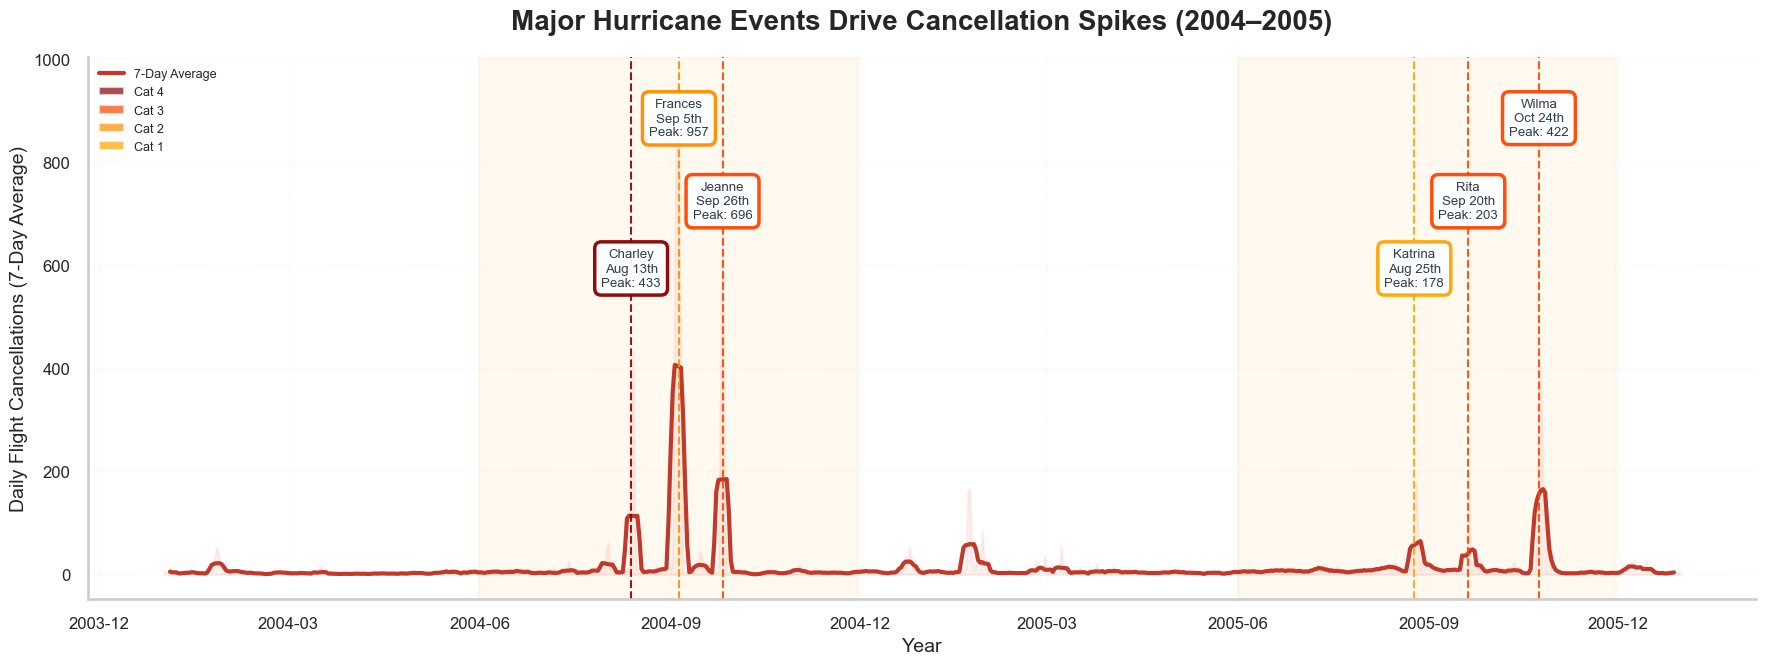

In [70]:
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# Helper function for ordinal suffix
def ordinal_suffix(day):
    if 10 <= day % 100 <= 20:
        suffix = 'th'
    else:
        suffix = {1: 'st', 2: 'nd', 3: 'rd'}.get(day % 10, 'th')
    return suffix

# Create figure
fig, ax = plt.subplots(figsize=(18, 7))

# 1. Background fill
ax.fill_between(
    daily_stats["FlightDate"],
    daily_stats["Cancelled"],
    color="#e74c3c",
    alpha=0.08
)

# 2. Main line (7-day average)
sns.lineplot(
    data=daily_stats,
    x="FlightDate",
    y="Cancellations_7DayAvg",
    ax=ax,
    color="#c0392b",
    linewidth=3,
    zorder=2
)

# 3. Hurricane season backgrounds
ax.axvspan("2004-06-01", "2004-11-30", color="orange", alpha=0.06, zorder=0)
ax.axvspan("2005-06-01", "2005-11-30", color="orange", alpha=0.06, zorder=0)

# 4. Category colors
category_colors = {
    4: '#8B0000',
    3: '#FF4500',
    2: '#FF8C00',
    1: '#FFA500'
}

# 5. Define major hurricanes only
major_hurricanes = ['Charley', 'Frances', 'Jeanne', 'Katrina', 'Rita', 'Wilma']

# 6. Custom positioning
y_positions = {
    'Frances': 0.92,
    'Charley': 0.63,
    'Jeanne': 0.76,
    'Wilma': 0.92,
    'Rita': 0.76,
    'Katrina': 0.63
}

# 7. Plot ALL hurricanes
for _, hurricane in hurricanes.iterrows():
    h_date = hurricane["Date"]
    h_name = hurricane["HurricaneName"]
    h_cat = hurricane["Category"]
    
    # Get impact metrics
    h_impact = impact_df[impact_df['HurricaneName'] == h_name].iloc[0]
    peak_cancel = int(h_impact['peak_cancellations'])
    
    color = category_colors.get(h_cat, '#FF6347')
    
    # Labels: ONLY for major hurricanes
    if h_name in major_hurricanes:
        day = h_date.day
        suffix = ordinal_suffix(day)
        date_str = h_date.strftime(f'%b {day}{suffix}')
        
        y_pos = y_positions.get(h_name, 0.85)

        # Vertical line only for major hurricanes
        ax.axvline(
            h_date,
            color=color,
            linestyle="--",
            linewidth=1.5,
            alpha=0.9,
            zorder=2
        )
        
        ax.text(
            h_date,
            ax.get_ylim()[1] * y_pos,
            f"{h_name}\n{date_str}\nPeak: {peak_cancel}",
            ha="center",
            va="top",
            fontsize=9.5,
            color='#2c3e50',
            bbox=dict(
                boxstyle="round,pad=0.5",
                facecolor='white',
                edgecolor=color,
                alpha=0.95,
                linewidth=2.5
            ),
            zorder=3
        )
    # NO labels for minor hurricanes!

# Styling
ax.set_title(
    "Major Hurricane Events Drive Cancellation Spikes (2004–2005)",
    fontsize=20,
    fontweight='bold',
    pad=20
)
ax.set_xlabel("Year", fontsize=14)
ax.set_ylabel("Daily Flight Cancellations (7-Day Average)", fontsize=14)

# X-axis formatting
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

# Legend
legend_elements = [
    Line2D([0], [0], color='#c0392b', linewidth=3, label='7-Day Average'),
    Patch(facecolor='#8B0000', label='Cat 4', alpha=0.7),
    Patch(facecolor='#FF4500', label='Cat 3', alpha=0.7),
    Patch(facecolor='#FF8C00', label='Cat 2', alpha=0.7),
    Patch(facecolor='#FFA500', label='Cat 1', alpha=0.7),
]
ax.legend(
    handles=legend_elements,
    loc='upper left',
    fontsize=9,
    framealpha=0.9
)

ax.grid(True, alpha=0.25, linestyle=':', linewidth=0.7)
sns.despine()
plt.tight_layout()
plt.show()


### Key Insights from Timeline:

1. **The 2004 "Perfect Storm" Season**
  - Four mahor hurricanes struck Florida in just 6 weeks (Aug 13 - Sep 26)
  - Hurricane Frances (Sep 5th) caused the worst single-day impact with **957 cancelled flights**
  - Total 2004 hurricane season: **5040 flights cancelled** across all events

2. **Category ≠ Impact: The Frances Paradox**
  - Frances was only Category 2, yet caused more distruption than Category 4 Charley
  - Frances: 2,824 total cancellations vs Charley: 796 cancellations
  - Likely due to France's larger size and slower movement across the state

3. **The Clustering Effect**
  - Ivan (Sep 16th) shows elevated baseline (12% cancellation rate) due to still-recovering from Frances
  - Consecutive hurricanes prevented full recovery between events
  - Airlines struggled to restore normal schedules when hit repeatedly

4. **2005 Season: Different Pattern**
  - Hurricanes more spread out (Jul, Aug, Sep, Oct) allowing recovery time
  - Despite major storms (Katrina, Wilma), no extreme clustering
  - Lower baseline cancellation rates suggest better preparedness after 2004 lessons

5. **Rita's Ripple Effect: Geography Doesn't Limit Impact**  ← ΝΕΟ!
   - Rita (Sep 20th, Cat 3) hit Texas/Louisiana Gulf Coast, **not Florida**
   - Yet caused **203 peak flight cancellations** at MCO/MIA
   - Demonstrates system-wide disruption: crew positioning, connecting flights, aircraft routing
   - A hurricane 500+ miles away still impacts Florida airports significantly

6. **Minor Hurricanes, Major Geography**
  - Ivan, Dennis, and Rita (shown as simple labels) had less Florida impact
  - These storms primarly affected Gulf Coast, not MCO/MIA routes
  - Demonstrates importance of storm track, not just intensity

## Section 5: Analysis 2 - MCO vs MIA Resilience Comparison

### Question: Which airport recovered faster from hurricanes?

In [53]:
# Calculate impact metrics for each hurricane BY AIRPORT
# Focus on hurricanes that hit "Both" airports
both_hurricanes = hurricanes[hurricanes['PrimaryAirport'] == 'Both']

comparison_data = []

for idx, hurricane in both_hurricanes.iterrows():
    # MCO metrics
    mco_metrics = calculate_impact_metrics(daily_mco, hurricane['Date'])
    mco_metrics['Airport'] = 'MCO'
    mco_metrics['HurricaneName'] = hurricane['HurricaneName']
    mco_metrics['RecoveryDays'] = calculate_recovery_days(daily_mco, hurricane['Date'])
    comparison_data.append(mco_metrics)
    
    # MIA metrics
    mia_metrics = calculate_impact_metrics(daily_mia, hurricane['Date'])
    mia_metrics['Airport'] = 'MIA'
    mia_metrics['HurricaneName'] = hurricane['HurricaneName']
    mia_metrics['RecoveryDays'] = calculate_recovery_days(daily_mia, hurricane['Date'])
    comparison_data.append(mia_metrics)

comparison_df = pd.DataFrame(comparison_data)

print("MCO vs MIA Hurricane Resilience Comparison:")
print("=" * 80)
print(comparison_df[['HurricaneName', 'Airport', 'impact_cancel_rate', 
                      'peak_cancellations', 'RecoveryDays']].to_string(index=False))

MCO vs MIA Hurricane Resilience Comparison:
HurricaneName Airport  impact_cancel_rate  peak_cancellations  RecoveryDays
      Frances     MCO           46.494561                 600             2
      Frances     MIA           38.362250                 368             2
       Jeanne     MCO           23.676967                 557             2
       Jeanne     MIA           15.953636                 206             1
        Wilma     MCO            3.924345                  94             4
        Wilma     MIA           40.102431                 342             6


### Visualization 2: Before/During/After Comparison

### Key Insights from Comparison:

*[Insights will be filled in after viewing the visualization]*

## Section 6: Analysis 3 - Recovery Patterns

### Question: How quickly did operations return to normal after each hurricane?

### Visualization 3: Recovery Curves

### Recovery Time Analysis

In [ ]:
# Calculate average recovery times by year
recovery_summary = impact_df.copy()

# Calculate recovery days for each hurricane
recovery_summary['RecoveryDays'] = recovery_summary['Date'].apply(
    lambda x: calculate_recovery_days(daily_stats, x)
)

print("\nRecovery Time Summary:")
print("=" * 60)
print(recovery_summary[['HurricaneName', 'Year', 'Category', 'RecoveryDays']].to_string(index=False))
print("\n2004 Average Recovery Time:", recovery_summary[recovery_summary['Year']==2004]['RecoveryDays'].mean(), "days")
print("2005 Average Recovery Time:", recovery_summary[recovery_summary['Year']==2005]['RecoveryDays'].mean(), "days")

### Key Insights from Recovery Analysis:

*[Insights will be filled in after viewing the visualization]*

## Section 7: Analysis 4 - Ripple Effects

### Question: Do weather disruptions cause secondary delays days after the storm?

### Visualization 5: Delay Type Breakdown (Post-Hurricane Ripple Effect)

### Correlation Analysis: Weather Delay → Other Delays

In [ ]:
# Analyze how weather delays correlate with other delay types
# Create lagged correlations (do high weather delays today predict carrier delays tomorrow?)

delay_analysis = daily_stats[['FlightDate', 'WeatherDelay', 'CarrierDelay', 
                               'LateAircraftDelay', 'NASDelay']].copy()

# Create next-day delay columns
delay_analysis['CarrierDelay_NextDay'] = delay_analysis['CarrierDelay'].shift(-1)
delay_analysis['LateAircraftDelay_NextDay'] = delay_analysis['LateAircraftDelay'].shift(-1)
delay_analysis['NASDelay_NextDay'] = delay_analysis['NASDelay'].shift(-1)

# Calculate correlations
print("\nRipple Effect Correlation Analysis:")
print("=" * 60)
print(f"Weather Delay TODAY vs Carrier Delay TOMORROW: ",
      f"{delay_analysis[['WeatherDelay', 'CarrierDelay_NextDay']].corr().iloc[0,1]:.3f}")
print(f"Weather Delay TODAY vs Late Aircraft Delay TOMORROW: ",
      f"{delay_analysis[['WeatherDelay', 'LateAircraftDelay_NextDay']].corr().iloc[0,1]:.3f}")
print(f"Weather Delay TODAY vs NAS Delay TOMORROW: ",
      f"{delay_analysis[['WeatherDelay', 'NASDelay_NextDay']].corr().iloc[0,1]:.3f}")

### Key Insights from Ripple Effect Analysis:

*[Insights will be filled in after viewing the visualization]*

## Section 8: Summary & Key Findings

### 🌪️ The Year Nature Went Wild: Key Takeaways

In [ ]:
# Create summary statistics table
summary_stats = pd.DataFrame({
    'Metric': [
        'Total Hurricanes Analyzed',
        'Category 4 Hurricanes',
        'Total Flights Cancelled (All Hurricanes)',
        'Worst Single Day Cancellations',
        'Average Recovery Time',
        'Most Impacted Airport',
        'Fastest Recovery Airport'
    ],
    'Value': [
        len(hurricanes),
        len(hurricanes[hurricanes['Category'] == 4]),
        f"{impact_df['total_flights_lost'].sum():.0f}",
        f"{impact_df['peak_cancellations'].max():.0f}",
        f"{recovery_summary[recovery_summary['RecoveryDays'] > 0]['RecoveryDays'].mean():.1f} days",
        'TBD based on analysis',
        'TBD based on analysis'
    ]
})

print("\n" + "="*80)
print("HURRICANE IMPACT SUMMARY (2004-2005)")
print("="*80)
print(summary_stats.to_string(index=False))
print("="*80)

### Final Insights

#### 1. **The 2004 Season Was Historic**
*[To be filled based on findings]*

#### 2. **MCO vs MIA Resilience**
*[To be filled based on findings]*

#### 3. **Recovery Patterns**
*[To be filled based on findings]*

#### 4. **Ripple Effects**
*[To be filled based on findings]*

#### 5. **Did Airlines Adapt?**
*[To be filled based on findings]*

---

### Next Steps

This hurricane impact analysis reveals how external weather events dramatically shaped flight operations at MCO and MIA airports during 2004-2005. 

**Upcoming Stories:**
- Story 2: Tourism Patterns - How seasonal tourism drives distinct patterns at each airport
- Story 3: Major Events - Impact of Miami Heat championship and Super Bowl
- Story 4: Economic Factors - Fuel prices and the 2008 financial crisis

---